# ELECTRICITY THEFT DETECTION USING MACHINE LEARNING

***MODULE 1 DATA COLLECTION & PREPROCESSING***

##### Global Configuration & Reproducibility Settings

In [2]:
CONFIG = {
    "RANDOM_STATE": 42,
    "TEST_SIZE": 0.2,
    "ZSCORE_THRESHOLD": 3,
    "INTERPOLATION_METHOD": "linear"
}


###### IMPORTING LIBRARIES

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


##### Data Loading and Initial Reshaping

In [4]:
df = pd.read_csv("data.csv")
df = df.rename(columns={"CONS_NO": "UserId", "FLAG": "IsStealer"})

date_cols = [c for c in df.columns if c not in ["UserId", "IsStealer"]]

df_melted = df.melt(
    id_vars=["UserId"],
    value_vars=date_cols,
    var_name="Reading_Date",
    value_name="Consumption_kWh"
)

df_melted["Reading_Date"] = pd.to_datetime(df_melted["Reading_Date"])
df_melted = df_melted.sort_values(["UserId", "Reading_Date"]).reset_index(drop=True)


##### Exploratory Data Analysis (EDA): Dataset Overview

In [5]:
# Basic structure
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

# Target distribution
print("\nTarget Distribution (IsStealer):")
print(df["IsStealer"].value_counts())
print(df["IsStealer"].value_counts(normalize=True))

# Consumption statistics
df_melted["Consumption_kWh"].describe()


Shape: (42372, 1036)

Columns:
 Index(['UserId', 'IsStealer', '2014/1/1', '2014/1/10', '2014/1/11',
       '2014/1/12', '2014/1/13', '2014/1/14', '2014/1/15', '2014/1/16',
       ...
       '2016/9/28', '2016/9/29', '2016/9/3', '2016/9/30', '2016/9/4',
       '2016/9/5', '2016/9/6', '2016/9/7', '2016/9/8', '2016/9/9'],
      dtype='object', length=1036)

Target Distribution (IsStealer):
IsStealer
0    38757
1     3615
Name: count, dtype: int64
IsStealer
0    0.914684
1    0.085316
Name: proportion, dtype: float64


count    3.257912e+07
mean     9.258860e+00
std      2.732241e+02
min      0.000000e+00
25%      7.300000e-01
50%      4.590000e+00
75%      9.740000e+00
max      8.000033e+05
Name: Consumption_kWh, dtype: float64

##### Exploratory Data Analysis (EDA): Missing Values and Zero Consumption Analysis

In [6]:
# Missing values
print("Missing values per column:")
print(df_melted.isna().sum())

# Zero consumption ratio
zero_ratio = (df_melted["Consumption_kWh"] == 0).mean()
print(f"Zero consumption ratio: {zero_ratio:.4f}")


Missing values per column:
UserId                    0
Reading_Date              0
Consumption_kWh    11233528
dtype: int64
Zero consumption ratio: 0.1321


##### Exploratory Data Analysis (EDA): Visual Distribution Analysis

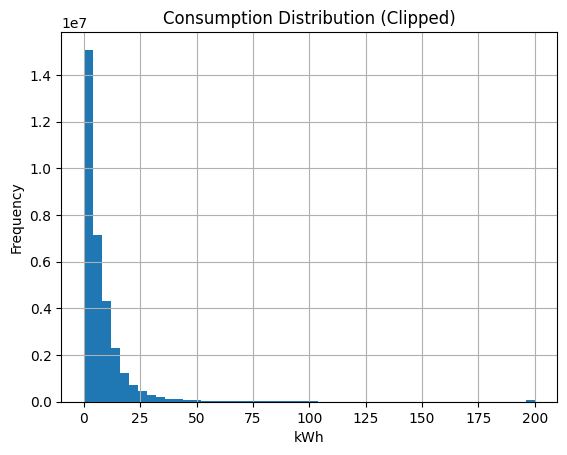

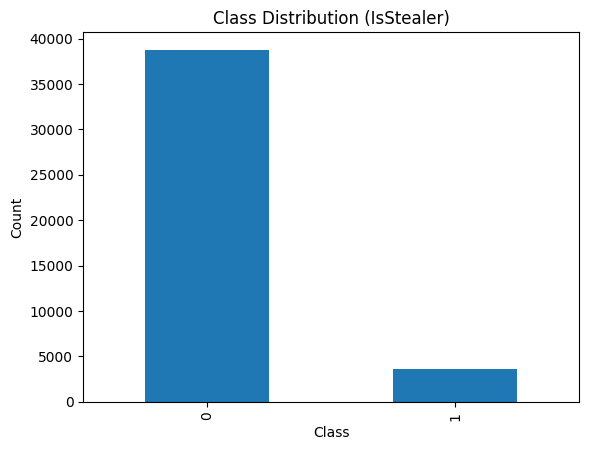

In [7]:
import matplotlib.pyplot as plt

# Consumption distribution
plt.figure()
df_melted["Consumption_kWh"].clip(upper=200).hist(bins=50)
plt.title("Consumption Distribution (Clipped)")
plt.xlabel("kWh")
plt.ylabel("Frequency")
plt.show()

# Class imbalance visualization
plt.figure()
df["IsStealer"].value_counts().plot(kind="bar")
plt.title("Class Distribution (IsStealer)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


##### Missing Value Imputation Strategy

In [8]:
def impute_series(s):
    s = s.interpolate(limit_direction="both").ffill()
    med = s[s > 0].median()
    return s.fillna(med if not np.isnan(med) and med > 0 else 0.1)

df_melted["Consumption_kWh"] = (
    df_melted.groupby("UserId")["Consumption_kWh"]
    .transform(impute_series)
)


In [9]:
split_date = df_melted["Reading_Date"].quantile(0.7)

train_df = df_melted[df_melted["Reading_Date"] <= split_date].copy()
test_df  = df_melted[df_melted["Reading_Date"] > split_date].copy()


##### Temporal Train–Test Split (Time-Aware)

In [10]:
print("Train date range:")
print(train_df["Reading_Date"].min(), "→", train_df["Reading_Date"].max())

print("\nTest date range:")
print(test_df["Reading_Date"].min(), "→", test_df["Reading_Date"].max())

assert train_df["Reading_Date"].max() < test_df["Reading_Date"].min(), \
    "❌ Data leakage detected: train overlaps test"


Train date range:
2014-01-01 00:00:00 → 2015-12-25 00:00:00

Test date range:
2015-12-26 00:00:00 → 2016-10-31 00:00:00


##### Z-Score Based Anomaly Detection

In [11]:
def zscore(x):
    return (x - x.mean()) / (x.std() + 1e-6)

train_df["zscore"] = (
    train_df.groupby("UserId")["Consumption_kWh"]
    .transform(zscore)
)

train_df["Theft_Event"] = (train_df["zscore"].abs() > 3).astype(int)


##### Future Theft Label Generation

In [12]:
future_events = (
    test_df.groupby("UserId")["Consumption_kWh"]
    .apply(lambda x: ((x - x.mean()) / (x.std() + 1e-6)).abs().max() > 3)
    .astype(int)
)

labels = future_events.rename("IsThief")


**Module 2 – Feature Engineering, Splitting,Model Building**

##### Feature Engineering Using Historical Consumption Pattern

In [13]:
train_df["lag1"] = train_df.groupby("UserId")["Consumption_kWh"].shift(1)
train_df["diff1"] = train_df["Consumption_kWh"] - train_df["lag1"]

features = train_df.groupby("UserId").agg(
    mean_cons=("Consumption_kWh", "mean"),
    std_cons=("Consumption_kWh", "std"),
    cv=("Consumption_kWh", lambda x: x.std() / (x.mean() + 1e-6)),
    zero_ratio=("Consumption_kWh", lambda x: (x == 0).mean()),
    max_diff=("diff1", "max"),
    event_rate=("Theft_Event", "mean"),
).fillna(0)


In [14]:
data = features.join(labels, how="inner")

X = data.drop(columns=["IsThief"])
y = data["IsThief"]


In [15]:
groups = X.index

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


##### Baseline Model: Majority Class Predictor

In [16]:
from sklearn.metrics import f1_score

# Majority class baseline
majority_class = y_train.mode()[0]
baseline_preds = [majority_class] * len(y_test)

baseline_f1 = f1_score(y_test, baseline_preds)
print("Baseline Majority Class F1:", round(baseline_f1, 4))


Baseline Majority Class F1: 0.8824


##### Decision Tree Classifier Training

In [17]:
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


##### Random Forest Classifier Training

In [18]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
feature_importance


Feature Importance:


mean_cons     0.283210
zero_ratio    0.207885
cv            0.147514
event_rate    0.132557
std_cons      0.130817
max_diff      0.098017
dtype: float64

##### XGBoost Classifier Training with Class Imbalance Handling

In [20]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=pos_weight,
    eval_metric="aucpr",
    tree_method="hist",
    random_state=RANDOM_STATE
)

xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


***Module 3 – Model Comparison and Optimization***

##### Comparative Performance Evaluation of All Model

In [21]:
def evaluate_model(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.6, 100)

    best_f1, best_t = 0, 0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y, preds)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return {
        "Best Threshold": round(best_t, 3),
        "F1": round(best_f1, 4),
        "ROC-AUC": round(roc_auc_score(y, probs), 4),
        "PR-AUC": round(average_precision_score(y, probs), 4)
    }


In [22]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    print(f"\n{name}")
    results = evaluate_model(model, X_test, y_test)
    for k, v in results.items():
        print(f"{k}: {v}")



Decision Tree
Best Threshold: 0.145
F1: 0.8892
ROC-AUC: 0.7103
PR-AUC: 0.8761

Random Forest
Best Threshold: 0.191
F1: 0.8903
ROC-AUC: 0.7287
PR-AUC: 0.8915

XGBoost
Best Threshold: 0.13
F1: 0.8888
ROC-AUC: 0.7088
PR-AUC: 0.8831


In [23]:
print(y_test.value_counts(normalize=True))


IsThief
1    0.789499
0    0.210501
Name: proportion, dtype: float64


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from joblib import dump
import pandas as pd
import numpy as np
import os


In [25]:
def evaluate_all_metrics(model, X, y):
    probs = model.predict_proba(X)[:, 1]

    # threshold optimization for F1
    thresholds = np.linspace(0.05, 0.6, 200)
    best_f1, best_t = 0, 0

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y, preds)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    final_preds = (probs >= best_t).astype(int)

    return {
        "Threshold": round(best_t, 3),
        "Accuracy": round(accuracy_score(y, final_preds), 4),
        "Precision": round(precision_score(y, final_preds), 4),
        "Recall": round(recall_score(y, final_preds), 4),
        "F1": round(f1_score(y, final_preds), 4),
        "ROC-AUC": round(roc_auc_score(y, probs), 4),
        "PR-AUC": round(average_precision_score(y, probs), 4)
    }


##### Final Model Comparison and Best Model Selection

In [26]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []
best_model_name = None
best_model = None
best_f1 = -1

for name, model in models.items():
    metrics = evaluate_all_metrics(model, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

    if metrics["F1"] > best_f1:
        best_f1 = metrics["F1"]
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results)

# reorder columns (clean table)
results_df = results_df[
    ["Model", "Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
]

print("\nFINAL MODEL COMPARISON TABLE\n")
print(results_df.to_markdown(index=False))



FINAL MODEL COMPARISON TABLE

| Model         |   Threshold |   Accuracy |   Precision |   Recall |     F1 |   ROC-AUC |   PR-AUC |
|:--------------|------------:|-----------:|------------:|---------:|-------:|----------:|---------:|
| Decision Tree |       0.141 |     0.8119 |      0.8314 |   0.9556 | 0.8892 |    0.7103 |   0.8761 |
| Random Forest |       0.177 |     0.8131 |      0.8294 |   0.961  | 0.8903 |    0.7287 |   0.8915 |
| XGBoost       |       0.13  |     0.8107 |      0.8288 |   0.9582 | 0.8888 |    0.7088 |   0.8831 |


##### Confusion Matrix and Classification Report Analysis

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

# Use best threshold from evaluation
probs = best_model.predict_proba(X_test)[:, 1]
best_threshold = results_df.loc[
    results_df["Model"] == best_model_name, "Threshold"
].values[0]

final_preds = (probs >= best_threshold).astype(int)

cm = confusion_matrix(y_test, final_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, final_preds))


Confusion Matrix:
 [[ 460 1324]
 [ 261 6430]]

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.26      0.37      1784
           1       0.83      0.96      0.89      6691

    accuracy                           0.81      8475
   macro avg       0.73      0.61      0.63      8475
weighted avg       0.79      0.81      0.78      8475



##### Model Persistence and Saving for Deployment

In [28]:
os.makedirs("saved_models", exist_ok=True)

model_path = f"saved_models/best_model_{best_model_name.replace(' ', '_')}.joblib"
dump(best_model, model_path)

print(f"\nBest Model Saved Successfully!")
print(f"Model Name : {best_model_name}")
print(f"F1 Score   : {best_f1}")
print(f"Saved Path : {model_path}")



Best Model Saved Successfully!
Model Name : Random Forest
F1 Score   : 0.8903
Saved Path : saved_models/best_model_Random_Forest.joblib


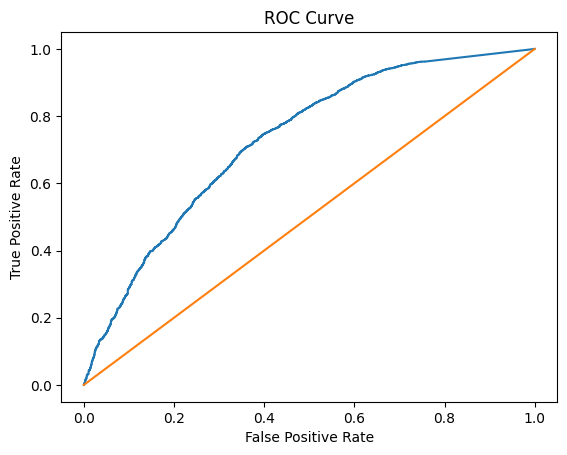

ROC-AUC Score: 0.7287


In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_probs = best_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_test, y_probs)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC Score:", round(roc_auc, 4))

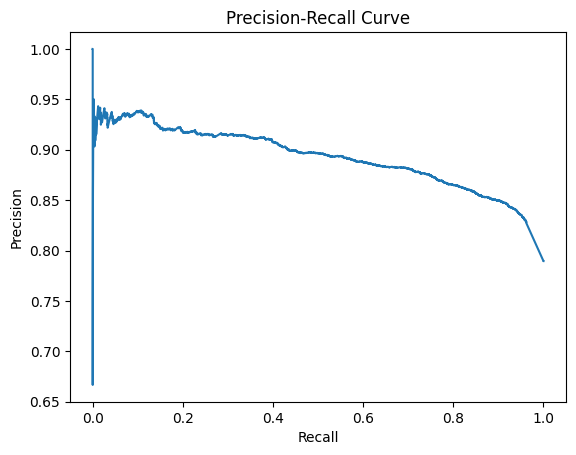

PR-AUC Score: 0.8915


In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get predicted probabilities
y_probs = best_model.predict_proba(X_test)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Compute PR-AUC
pr_auc = average_precision_score(y_test, y_probs)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

print("PR-AUC Score:", round(pr_auc, 4))

In [30]:
FEATURE_COLUMNS = [
    "mean_cons",
    "std_cons",
    "cv",
    "zero_ratio",
    "max_diff",
    "event_rate"
]

In [32]:
# =========================================
# INTERACTIVE INFERENCE CELL (USER INPUT)
# =========================================

from joblib import load
import pandas as pd

# Load model (if not already loaded)
best_model = load("saved_models/best_model_Random_Forest.joblib")

FEATURE_COLUMNS = [
    "mean_cons",
    "std_cons",
    "cv",
    "zero_ratio",
    "max_diff",
    "event_rate"
]

BEST_THRESHOLD = 0.177

def predict_user():

    print("\nEnter feature values:")

    mean_cons = float(input("Mean Consumption: "))
    std_cons = float(input("Std Consumption: "))
    cv = float(input("Coefficient of Variation (CV): "))
    zero_ratio = float(input("Zero Consumption Ratio: "))
    max_diff = float(input("Max Consumption Difference: "))
    event_rate = float(input("Event Rate: "))

    input_df = pd.DataFrame([[
        mean_cons,
        std_cons,
        cv,
        zero_ratio,
        max_diff,
        event_rate
    ]], columns=FEATURE_COLUMNS)

    prob = best_model.predict_proba(input_df)[0][1]

    if prob >= BEST_THRESHOLD:
        prediction = "Theft Detected"
        risk_color = "red"
    else:
        prediction = "Normal Usage"
        risk_color = "green"

    print("\n=========== PREDICTION OUTPUT ===========")
    print("Prediction        :", prediction)
    print("Risk Color        :", risk_color)
    print("Theft Probability :", round(float(prob), 4))
    print("Decision Threshold:", BEST_THRESHOLD)
    print("=========================================\n")


# Run prediction
predict_user()


Enter feature values:


Mean Consumption:  8.5
Std Consumption:  3.2
Coefficient of Variation (CV):  0.4
Zero Consumption Ratio:  0.1
Max Consumption Difference:  2.0
Event Rate:  0.05



=========== PREDICTION OUTPUT ===========
Prediction        : Theft Detected
Risk Color        : red
Theft Probability : 0.5642
Decision Threshold: 0.177

